In [1]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Fadillah Dama Rifky'  # GANTI
NIM = '244107020149'               # GANTI: NIM contoh, bukan NIM Anda

N = int(NIM[-3:])
PARAM = {
    'bins': 2 ** ((N % 4) + 3),
    'clip': round(1.0 + (N % 5) * 0.5, 1),
    'tile': (N % 4) + 2,
    'L': 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA   :', NAMA)
print('NIM    :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])


NAMA   : Fadillah Dama Rifky
NIM    : 244107020149 | N = 149
bins   : 16
clip   : 3.0
tile   : 3
L      : 8
WAKTU  : 2026-09-30 22:46:12 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : 8b1b3e2df100051d


# MODUL 5 — HISTOGRAM, HISTOGRAM EQUALIZATION, DAN DITHERING

Notebook Fadillah Dama Rifky.

**Panduan urutan:** persiapan → E1 Percobaan → E1 Pertanyaan → E2 Percobaan → E2 Pertanyaan → E3 Tugas.

Judul pada **sel teks** menjelaskan posisi setiap langkah dalam modul. Isi seluruh sel kode dan output asli dipertahankan. Beberapa kode awal mengerjakan dua kebutuhan sekaligus; rujukan di bawah menunjukkan hasil yang dipakai bersama tanpa menggandakan kode.

Jalankan notebook dari atas ke bawah karena beberapa sel tampilan menggunakan variabel dari sel sebelumnya. Nomor eksekusi pada output adalah nomor dari pengerjaan sebelumnya, bukan nomor urutan bagian modul.


## PERSIAPAN — E1 PERCOBAAN 1–2

**Percobaan 1:** persiapan notebook dan identitas. Sel identitas tetap menjadi sel pertama. Ketentuan nama notebook mengikuti `Week5_<No Absen>.ipynb` pada modul.

**Percobaan 2:** import library, menghubungkan Google Drive, dan menyiapkan alamat gambar.


### PERSIAPAN — Import library dan lokasi gambar

Memuat OpenCV, NumPy, Matplotlib, menghubungkan Drive, dan menetapkan path enam gambar yang dipakai.

In [19]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

# Ganti folder sesuai lokasi gambar Anda. Drive sudah terhubung.

BASE = '/content/drive/MyDrive/PCVK'

# Ganti nama file di sini jika berbeda.
file_lena = BASE + '/lena.jpg'
file_lena_lc = BASE + '/lena_lc.jpg'
file_a = BASE + '/KTM1a.jpg'
file_b = BASE + '/KTM1b.jpg'
file_c = BASE + '/KTM1c.jpg'
file_d = BASE + '/KTM1d.jpg'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# E1 — HISTOGRAM

## E1 PERCOBAAN 3 — Membuat histogram manual

Pada modul, langkah pembuatan histogram berada pada **Percobaan nomor 3**; nomor 1–2 adalah persiapan. Fungsi di bawah menghitung kemunculan tiap intensitas piksel.

**Rujukan hasil percobaan:** pembacaan gambar dan grafik Lena/KTM1b ada pada **E1 Pertanyaan 1** karena sel asli sekaligus menghitung histogram manual, NumPy, dan OpenCV. Fungsi tetap ditempatkan di sini agar tersedia sebelum dipakai. Kode tidak diduplikasi.


### E1 PERCOBAAN 3 — Fungsi histogram manual

Menelusuri baris dan kolom citra, kemudian menambahkan frekuensi pada intensitas yang sesuai.

In [3]:
# E1 - PERCOBAAN 1 dan PERTANYAAN 1

def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1
    return h


## E1 — PERTANYAAN PRAKTIKUM

Bagian berikut memuat Pertanyaan 1, 2, dan 3 secara berurutan.


### E1 PERTANYAAN 1 — Tahap 1: Lena

Menghitung histogram dengan tiga metode, membuktikan selisih maksimum nol, dan menampilkan citra serta histogram. Histogram manualnya sekaligus menjadi hasil E1 Percobaan 3 pada citra contoh.

Manual - NumPy: 0
Manual - OpenCV: 0
NumPy - OpenCV: 0


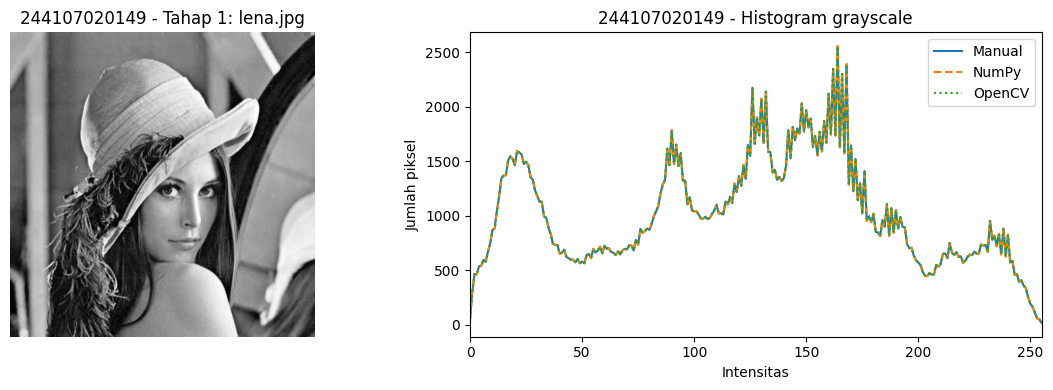

In [13]:
# TAHAP 1
# Baca gambar dan ubah menjadi grayscale.
bgr = cv.imread(file_lena)
gray = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)

# 2. Hitung histogram dengan tiga cara.
h_manual = histogram_manual(gray)
h_numpy, tepi = np.histogram(gray, bins=256, range=(0, 256))
h_cv = cv.calcHist([gray], [0], None, [256], [0, 256])
h_cv = h_cv.flatten().astype(np.int64)

# 3. Bandingkan hasil. Selisih maksimum seharusnya 0.
print('Manual - NumPy:', np.max(np.abs(h_manual - h_numpy)))
print('Manual - OpenCV:', np.max(np.abs(h_manual - h_cv)))
print('NumPy - OpenCV:', np.max(np.abs(h_numpy - h_cv)))
assert h_manual.sum() == gray.size
assert np.array_equal(h_manual, h_numpy)
assert np.array_equal(h_manual, h_cv)

# 4. Tampilkan citra dan ketiga histogram pada satu grafik.
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray', vmin=0, vmax=255)
plt.title(NIM + ' - Tahap 1: lena.jpg')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.plot(h_manual, label='Manual')
plt.plot(h_numpy, '--', label='NumPy')
plt.plot(h_cv, ':', label='OpenCV')
plt.title(NIM + ' - Histogram grayscale')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah piksel')
plt.xlim(0, 255)
plt.legend()
plt.tight_layout()
plt.show()


### E1 PERTANYAAN 1 — Grafik pendukung kanal warna Lena

Menampilkan histogram manual biru, hijau, dan merah untuk gambar Lena yang dibaca pada sel sebelumnya.

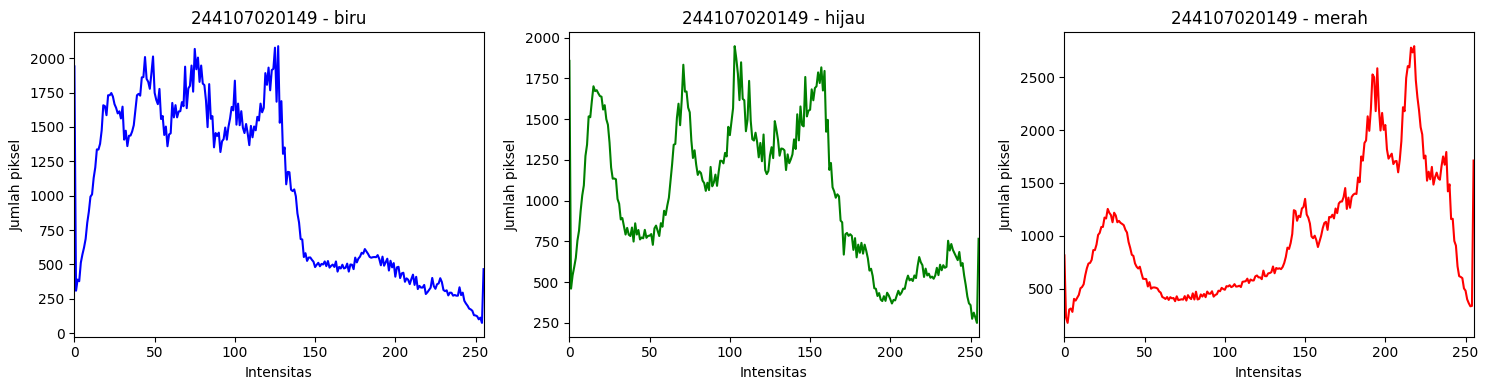

In [14]:
# Hitung histogram masing-masing kanal warna.
h_biru = histogram_manual(bgr[:, :, 0])
h_hijau = histogram_manual(bgr[:, :, 1])
h_merah = histogram_manual(bgr[:, :, 2])

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(h_biru, color='blue')
plt.title(NIM + ' - biru')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah piksel')
plt.xlim(0, 255)

plt.subplot(1, 3, 2)
plt.plot(h_hijau, color='green')
plt.title(NIM + ' - hijau')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah piksel')
plt.xlim(0, 255)

plt.subplot(1, 3, 3)
plt.plot(h_merah, color='red')
plt.title(NIM + ' - merah')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah piksel')
plt.xlim(0, 255)

plt.tight_layout()
plt.show()


### E1 PERTANYAAN 1 — Tahap 2: KTM1b

Mengulang pembandingan manual, NumPy, dan OpenCV pada citra pribadi. Histogram manualnya sekaligus menjadi hasil E1 Percobaan 3 pada KTM1b.

Manual - NumPy: 0
Manual - OpenCV: 0
NumPy - OpenCV: 0


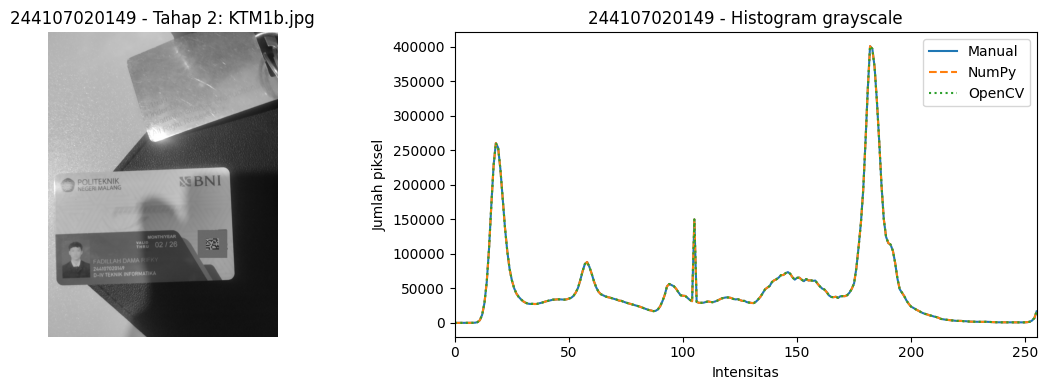

In [45]:
# TAHAP 2

# 1. Baca gambar dan ubah menjadi grayscale.
bgr = cv.imread(file_b)
gray = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)

# 2. Hitung histogram dengan tiga cara.
h_manual = histogram_manual(gray)
h_numpy, tepi = np.histogram(gray, bins=256, range=(0, 256))
h_cv = cv.calcHist([gray], [0], None, [256], [0, 256])
h_cv = h_cv.flatten().astype(np.int64)

# 3. Bandingkan hasil. Selisih maksimum seharusnya 0.
print('Manual - NumPy:', np.max(np.abs(h_manual - h_numpy)))
print('Manual - OpenCV:', np.max(np.abs(h_manual - h_cv)))
print('NumPy - OpenCV:', np.max(np.abs(h_numpy - h_cv)))
assert h_manual.sum() == gray.size
assert np.array_equal(h_manual, h_numpy)
assert np.array_equal(h_manual, h_cv)

# 4. Tampilkan citra dan ketiga histogram pada satu grafik.
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray', vmin=0, vmax=255)
plt.title(NIM + ' - Tahap 2: KTM1b.jpg')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.plot(h_manual, label='Manual')
plt.plot(h_numpy, '--', label='NumPy')
plt.plot(h_cv, ':', label='OpenCV')
plt.title(NIM + ' - Histogram grayscale')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah piksel')
plt.xlim(0, 255)
plt.legend()
plt.tight_layout()
plt.show()


### E1 PERTANYAAN 1 — Grafik pendukung kanal warna KTM1b

Menampilkan histogram kanal B, G, dan R dari KTM1b. Sel ini mengikuti sel pembacaan KTM1b agar gambar yang dipakai benar.

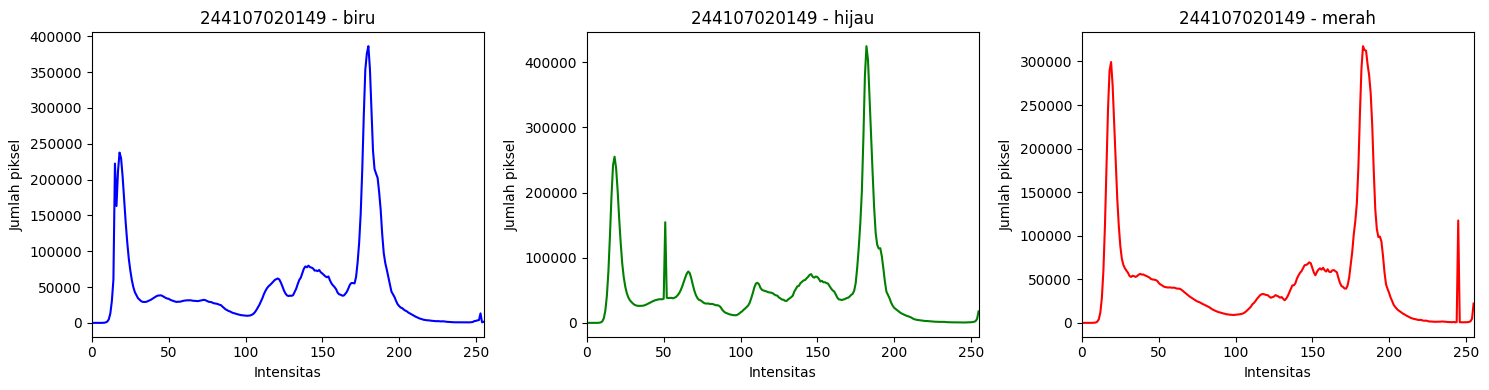

In [46]:
# Hitung histogram masing-masing kanal warna.
h_biru = histogram_manual(bgr[:, :, 0])
h_hijau = histogram_manual(bgr[:, :, 1])
h_merah = histogram_manual(bgr[:, :, 2])

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(h_biru, color='blue')
plt.title(NIM + ' - biru')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah piksel')
plt.xlim(0, 255)

plt.subplot(1, 3, 2)
plt.plot(h_hijau, color='green')
plt.title(NIM + ' - hijau')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah piksel')
plt.xlim(0, 255)

plt.subplot(1, 3, 3)
plt.plot(h_merah, color='red')
plt.title(NIM + ' - merah')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah piksel')
plt.xlim(0, 255)

plt.tight_layout()
plt.show()


### Jawaban E1 Pertanyaan 1

Berdasarkan hasil percobaan, selisih maksimum antara histogram manual, NumPy, dan OpenCV adalah **0**, baik pada Lena maupun KTM1b. Jadi, ketiga cara tersebut menghasilkan frekuensi intensitas yang sama. Hasilnya sama karena gambar, jumlah bin, dan rentang intensitas yang digunakan juga sama. Garis histogram yang saling menutupi menunjukkan hasil perhitungan ketiganya sesuai.

### E1 PERTANYAAN 2 — Histogram ternormalisasi dan CDF

Menampilkan KTM1a–KTM1d dalam layout 2 × 2, menghitung rerata intensitas, dan menentukan citra paling gelap serta paling terang menurut rerata.

KTM1a: gelap | rerata = 23.34
KTM1b: lampu | rerata = 120.28
KTM1c: flash | rerata = 105.28
KTM1d: matahari | rerata = 79.29


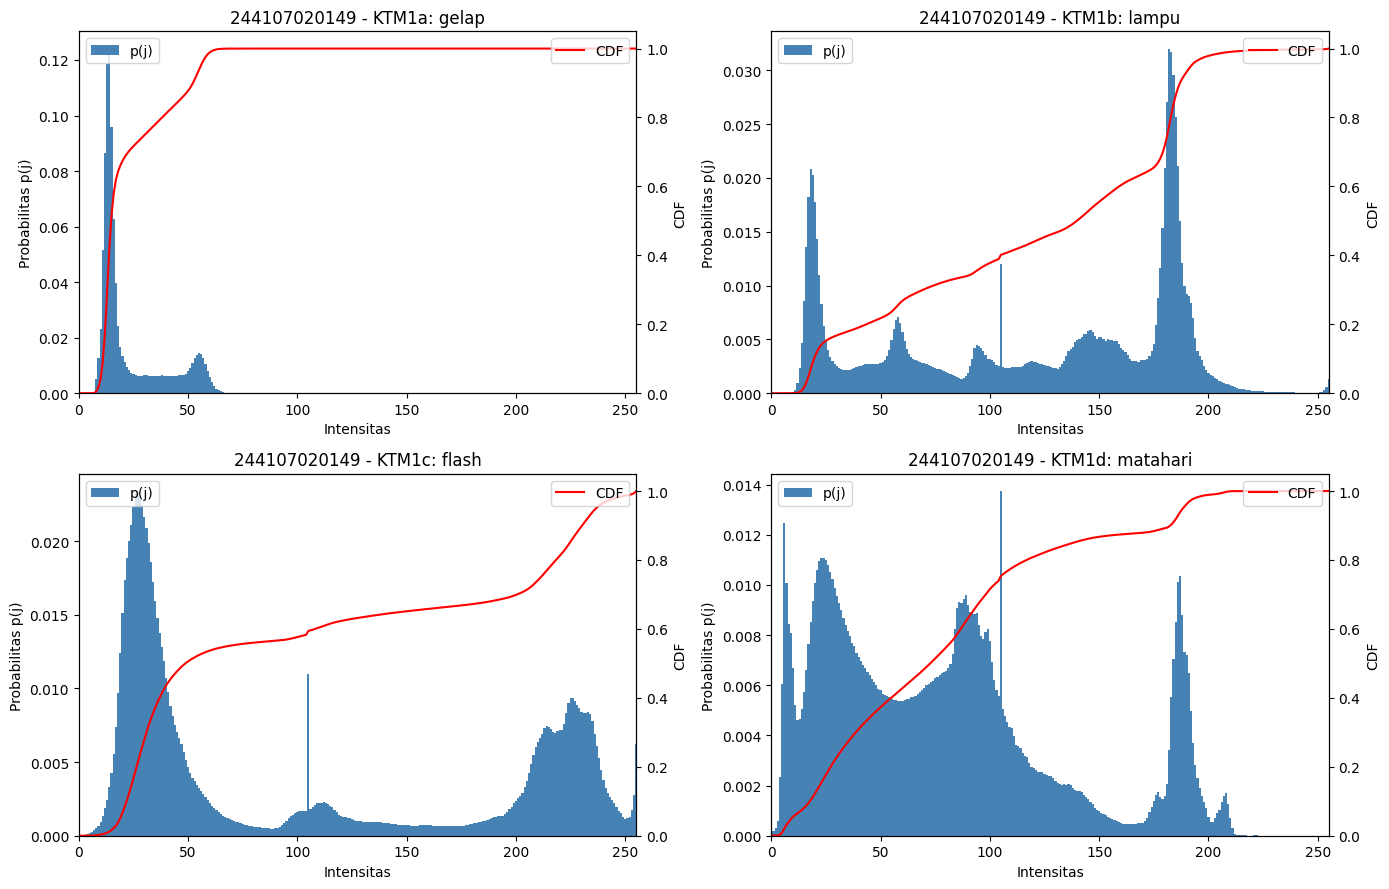

Paling gelap menurut rerata: KTM1a: gelap
Paling terang menurut rerata: KTM1b: lampu


In [48]:
# E1 - PERTANYAAN 2

# Empat gambar diperiksa bergantian dengan perulangan sederhana.
daftar_file = [file_a, file_b, file_c, file_d]
daftar_nama = ['KTM1a: gelap', 'KTM1b: lampu', 'KTM1c: flash', 'KTM1d: matahari']
rerata = []
plt.figure(figsize=(14, 9))

for i in range(4):
    bgr = cv.imread(daftar_file[i])
    gray = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)
    h, tepi = np.histogram(gray, bins=256, range=(0, 256))

    # Normalisasi histogram, kemudian jumlahkan secara kumulatif.
    p = h / gray.size
    cdf = np.cumsum(p)
    rerata.append(gray.mean())
    assert np.isclose(p.sum(), 1)
    assert np.isclose(cdf[-1], 1)

    plt.subplot(2, 2, i + 1)
    plt.bar(np.arange(256), p, width=1, color='steelblue', label='p(j)')
    plt.title(NIM + ' - ' + daftar_nama[i])
    plt.xlabel('Intensitas')
    plt.ylabel('Probabilitas p(j)')
    plt.xlim(0, 255)
    plt.legend(loc='upper left')

    # CDF menggunakan sumbu kanan agar skalanya terbaca.
    plt.twinx()
    plt.plot(cdf, color='red', label='CDF')
    plt.ylabel('CDF')
    plt.ylim(0, 1.05)
    plt.legend(loc='upper right')

    print(daftar_nama[i], '| rerata =', round(gray.mean(), 2))

plt.tight_layout()
plt.show()
print('Paling gelap menurut rerata:', daftar_nama[np.argmin(rerata)])
print('Paling terang menurut rerata:', daftar_nama[np.argmax(rerata)])


### Jawaban E1 Pertanyaan 2

| Citra | Kondisi pencahayaan | Rerata intensitas |
|---|---|---:|
| KTM1a | Ruangan gelap | 23,34 |
| KTM1b | Lampu ruangan | 120,28 |
| KTM1c | Flash | 105,28 |
| KTM1d | Cahaya matahari | 79,29 |

Dari hasil tersebut, **KTM1a merupakan citra paling gelap**, sedangkan **KTM1b paling terang** berdasarkan rerata intensitasnya. Pada KTM1a, CDF naik tajam di intensitas rendah dan sudah mendekati 1 sekitar intensitas 60. Artinya, sebagian besar piksel berada pada daerah gelap. Hasil ini sesuai dengan pengambilan gambar di ruangan gelap.

Pada KTM1b, CDF naik lebih bertahap dan terdapat kenaikan besar sekitar intensitas 180. Jadi, distribusinya memuat lebih banyak piksel terang dibandingkan KTM1a. KTM1c dengan flash memiliki kelompok piksel gelap dan terang, sehingga pencahayaannya tidak merata pada seluruh gambar.

Cahaya matahari pada KTM1d ternyata tidak menghasilkan rerata paling tinggi. Hal ini bisa dipengaruhi pengaturan otomatis kamera, bayangan, posisi kartu, dan latar yang ikut tertangkap. Jadi, kondisi pencahayaan tidak bisa dinilai dari nama sumber cahayanya saja.

### E1 PERTANYAAN 3 — Perbandingan jumlah bin

Membandingkan histogram KTM1b dengan jumlah bin berdasarkan NIM dan dengan 256 bin.

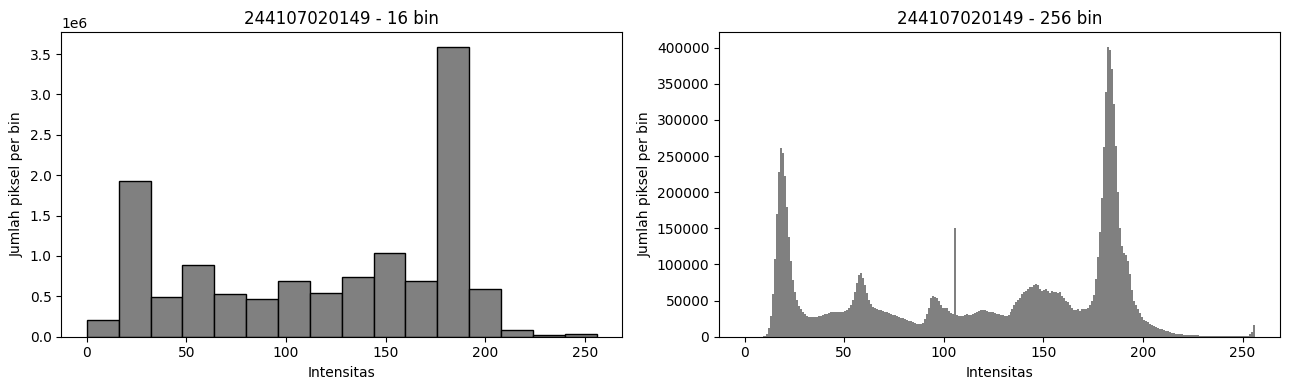

Lebar satu bin pribadi: 16 nilai intensitas


In [18]:
# E1 - PERTANYAAN 3

bgr = cv.imread(file_b)
gray = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)

plt.figure(figsize=(13, 4))
plt.subplot(1, 2, 1)
plt.hist(gray.flatten(), bins=PARAM['bins'], range=(0, 256), color='gray', edgecolor='black')
plt.title(NIM + ' - ' + str(PARAM['bins']) + ' bin')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah piksel per bin')

plt.subplot(1, 2, 2)
plt.hist(gray.flatten(), bins=256, range=(0, 256), color='gray')
plt.title(NIM + ' - 256 bin')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah piksel per bin')
plt.tight_layout()
plt.show()
print('Lebar satu bin pribadi:', 256 // PARAM['bins'], 'nilai intensitas')


### Jawaban E1 Pertanyaan 3

Berdasarkan NIM saya, jumlah bin yang digunakan adalah **16**. Setiap bin menggabungkan **16 nilai intensitas**, sedangkan histogram 256 bin menunjukkan frekuensi setiap intensitas secara terpisah.

Saat jumlah bin dikurangi, bentuk umum histogram masih terlihat, tetapi detail seperti puncak kecil dan perbedaan frekuensi pada intensitas yang berdekatan menjadi tidak terlihat. Jadi, histogram 16 bin lebih ringkas, sedangkan 256 bin memberikan informasi yang lebih rinci. Jumlah pikselnya tetap sama; yang berubah hanya pengelompokannya.

# E2 — HISTOGRAM EQUALIZATION

## E2 — PERCOBAAN

Percobaan 1–2 membahas HE manual dan OpenCV. Percobaan 3–4 membahas ekualisasi warna dan pengukurannya. Bagian **Pertanyaan Praktikum E2** ditempatkan setelah seluruh percobaan warna.


### E2 PERCOBAAN 1–2 — Tahap 1: HE manual dan OpenCV pada Lena LC

Sel asli menggabungkan Percobaan 1 (ekualisasi manual) dan Percobaan 2 (`cv.equalizeHist`) serta menghitung selisih keduanya; isi sel tetap dipertahankan.

In [20]:
# E2 PRAKTIKUM 2

bgr = cv.imread(file_lena_lc)
gray = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)

# HE manual: frekuensi -> probabilitas -> CDF -> intensitas baru.
h = histogram_manual(gray)
p = h / gray.size
cdf = np.cumsum(p)
pemetaan = np.round(255 * cdf).astype(np.uint8)
manual = pemetaan[gray]

# HE menggunakan OpenCV.
opencv = cv.equalizeHist(gray)

# Konversi ke int16 agar pengurangan tidak berputar seperti pada uint8.
selisih = np.abs(manual.astype(np.int16) - opencv.astype(np.int16))
print('Selisih maksimum manual - OpenCV:', selisih.max())


Selisih maksimum manual - OpenCV: 0


### E2 PERCOBAAN 1–2 — Tampilan citra dan histogram Lena LC

Menampilkan citra asli, HE manual, HE OpenCV, dan histogram masing-masing dalam satu layout.

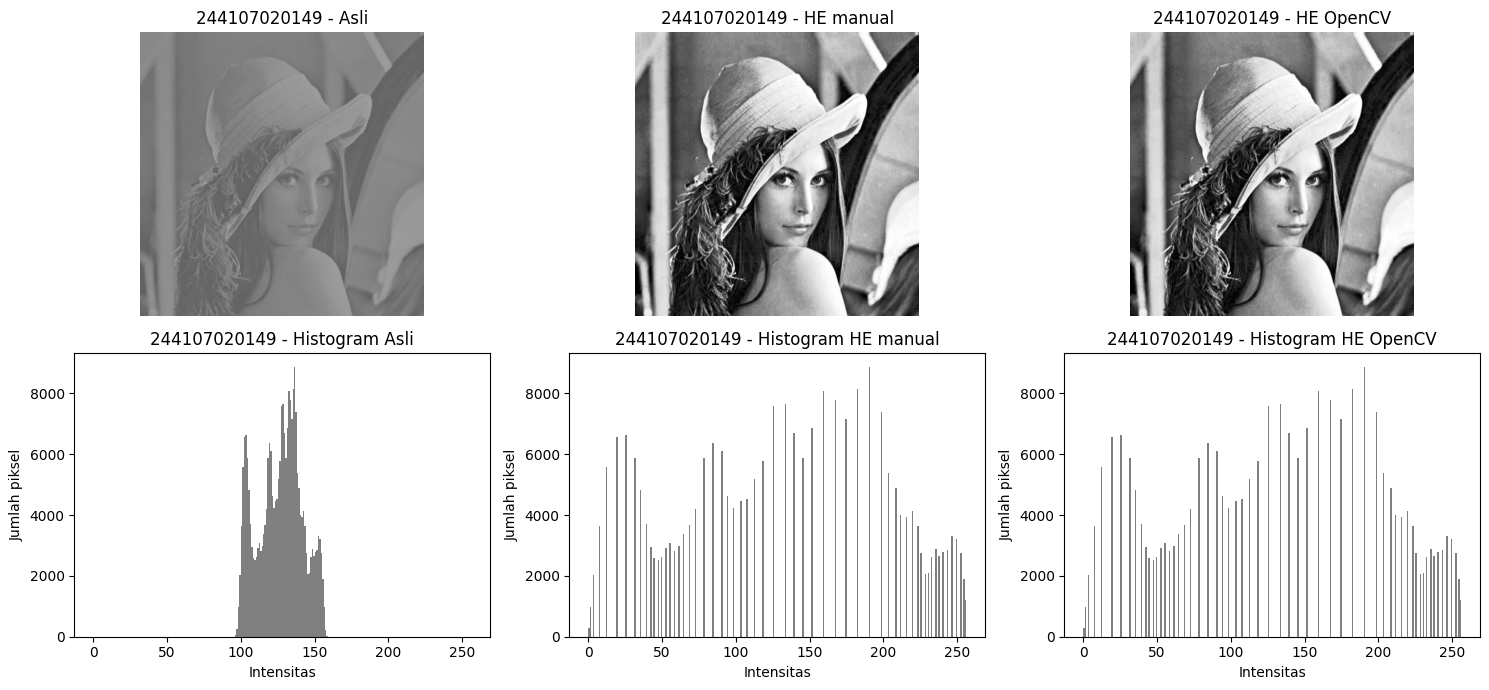

In [21]:
plt.figure(figsize=(15, 7))

plt.subplot(2, 3, 1)
plt.imshow(gray, cmap='gray', vmin=0, vmax=255)
plt.title(NIM + ' - Asli')
plt.axis('off')
plt.subplot(2, 3, 4)
plt.hist(gray.flatten(), bins=256, range=(0, 256), color='gray')
plt.title(NIM + ' - Histogram Asli')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah piksel')

plt.subplot(2, 3, 2)
plt.imshow(manual, cmap='gray', vmin=0, vmax=255)
plt.title(NIM + ' - HE manual')
plt.axis('off')
plt.subplot(2, 3, 5)
plt.hist(manual.flatten(), bins=256, range=(0, 256), color='gray')
plt.title(NIM + ' - Histogram HE manual')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah piksel')

plt.subplot(2, 3, 3)
plt.imshow(opencv, cmap='gray', vmin=0, vmax=255)
plt.title(NIM + ' - HE OpenCV')
plt.axis('off')
plt.subplot(2, 3, 6)
plt.hist(opencv.flatten(), bins=256, range=(0, 256), color='gray')
plt.title(NIM + ' - Histogram HE OpenCV')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah piksel')

plt.tight_layout()
plt.show()


### E2 PERCOBAAN 1–2 — Pengukuran tambahan PSNR Lena LC

Pengukuran tambahan yang sudah ada pada file asli. Tetap diletakkan sesudah HE Lena LC agar memakai variabel gambar yang tepat. PSNR untuk jawaban E2 Pertanyaan 1c berada pada bagian pertanyaan, menggunakan KTM1a.

In [22]:
# PSNR manual: ubah ke float sebelum menghitung selisih dan kuadrat.
mse_manual = np.mean((gray.astype(np.float64) - manual.astype(np.float64)) ** 2)
if mse_manual == 0:
    psnr_manual = float('inf')
else:
    psnr_manual = 10 * np.log10(255 ** 2 / mse_manual)

mse_opencv = np.mean((gray.astype(np.float64) - opencv.astype(np.float64)) ** 2)
if mse_opencv == 0:
    psnr_opencv = float('inf')
else:
    psnr_opencv = 10 * np.log10(255 ** 2 / mse_opencv)

print('PSNR asli - manual:', psnr_manual, 'dB')
print('PSNR asli - OpenCV:', psnr_opencv, 'dB')


PSNR asli - manual: 12.723209918705944 dB
PSNR asli - OpenCV: 12.723209918705944 dB


### Hasil E2 Percobaan 1–2 — Lena LC

Pada Lena LC, selisih maksimum antara hasil manual dan `cv.equalizeHist` adalah **0**. Nilai PSNR keduanya terhadap citra asli juga sama, yaitu sekitar **12,72 dB**. Jadi, untuk gambar yang digunakan pada percobaan ini, hasil kedua cara ekualisasi sama.

**Tahap 2 pada citra pribadi:** HE manual, HE OpenCV, dan histogram KTM1a tersedia di **E2 Pertanyaan 1a–1b**. Hasil tersebut juga memenuhi tahap KTM1a pada Percobaan 1–2; kode diletakkan sekali pada bagian pertanyaan.

### E2 PERCOBAAN 3–4 — Pengantar ekualisasi warna

Pada file asli, ekualisasi B/G/R (Percobaan 3) dan ekualisasi kanal Y/V/L (Percobaan 4) ditulis dalam satu sel untuk setiap gambar. Sel ini dipertahankan utuh, sehingga diberi label **Percobaan 3–4**. Keduanya tetap berada dalam kelompok percobaan.


### E2 PERCOBAAN 4 — Persiapan fungsi pengukuran Hue

Fungsi dipersiapkan sebelum percobaan warna. Menghitung jarak Hue melingkar untuk menilai pergeseran warna.

In [26]:
# E2 PERCOBAAN 3
def geser_hue(asli, hasil):
    h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
    d = np.abs(h1 - h2)
    d = np.minimum(d, 180 - d)
    return d.mean()


### E2 PERCOBAAN 3–4 — Tahap 1: Proses ekualisasi warna Lena

Percobaan 3: mengekualisasi kanal B, G, dan R. Percobaan 4: mengekualisasi kanal Y, V, dan L sambil mempertahankan kanal lainnya.

In [27]:
# TAHAP 1
bgr = cv.imread(file_lena)

# Cara 1: ekualisasi masing-masing kanal B, G, dan R.
b, g, r = cv.split(bgr)
b = cv.equalizeHist(b)
g = cv.equalizeHist(g)
r = cv.equalizeHist(r)
he_rgb = cv.merge([b, g, r])

# Cara 2: hanya kanal kecerahan Y; Cr dan Cb tetap.
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

# Cara 3: hanya kanal V; H dan saturasi tetap.
hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

# Cara 4: hanya kanal L; a dan b tetap.
lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)


### E2 PERCOBAAN 3–4 — Tahap 1: Tampilan dan pengukuran Lena

Menampilkan lima citra, mengukur pergeseran Hue dan kecerahan, serta menunjukkan metode dengan pergeseran Hue terbesar.

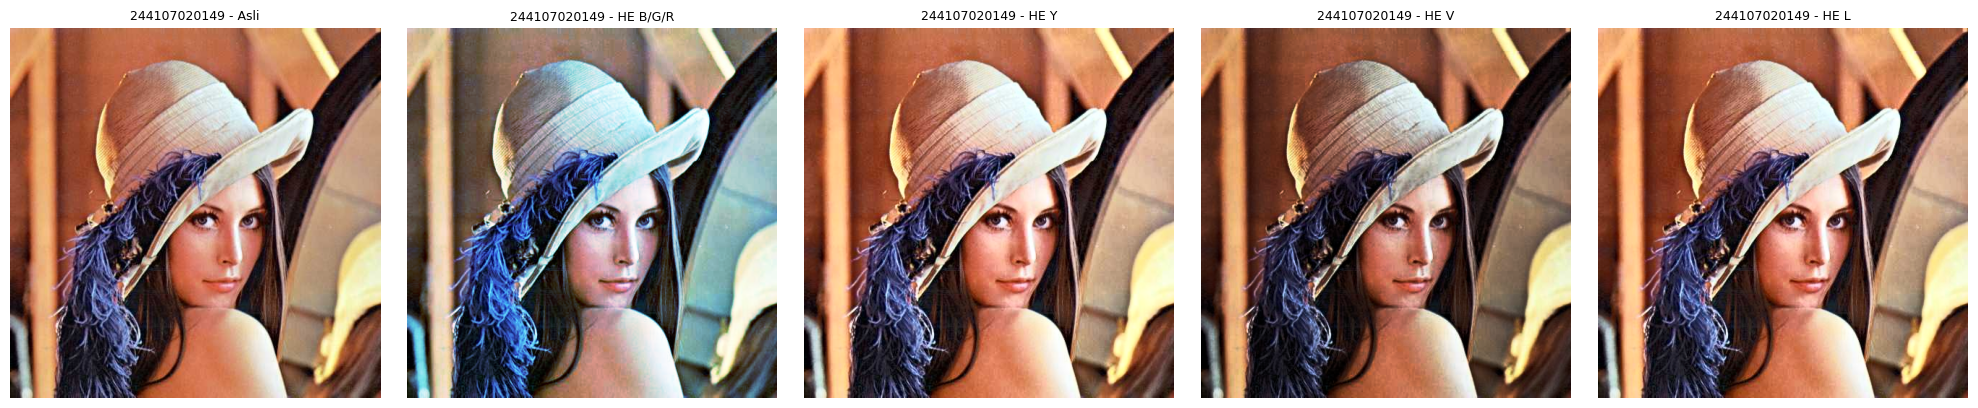

Cara | Pergeseran Hue (derajat) | Rerata kecerahan
Asli | 0.0 | 122.24
HE B/G/R | 53.0257 | 127.37
HE Y | 0.4047 | 127.9
HE V | 0.8728 | 100.55
HE L | 1.6529 | 122.72
Pergeseran terbesar: HE B/G/R = 53.0257 derajat


In [28]:
# Perulangan dipakai karena cara menampilkan kelima citra sama.
citra = [bgr, he_rgb, he_y, he_v, he_l]
judul = ['Asli', 'HE B/G/R', 'HE Y', 'HE V', 'HE L']
plt.figure(figsize=(20, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(cv.cvtColor(citra[i], cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + judul[i], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

# Cetak tabel angka untuk menjawab pertanyaan modul.
print('Cara | Pergeseran Hue (derajat) | Rerata kecerahan')
nilai_hue = []
for i in range(5):
    hue = geser_hue(bgr, citra[i]) * 2
    terang = cv.cvtColor(citra[i], cv.COLOR_BGR2GRAY).mean()
    nilai_hue.append(hue)
    print(judul[i], '|', round(hue, 4), '|', round(terang, 2))

# Cari nilai terbesar di antara empat metode ekualisasi, bukan citra asli.
hue_terbesar = max(nilai_hue[1:])
for i in range(1, 5):
    if nilai_hue[i] == hue_terbesar:
        print('Pergeseran terbesar:', judul[i], '=', round(hue_terbesar, 4), 'derajat')


### Hasil E2 Percobaan 3–4 — Lena

Pada Lena, ekualisasi B/G/R menghasilkan pergeseran Hue terbesar, yaitu **53,0257°**. Pergeseran pada kanal Y hanya **0,4047°**, kanal V **0,8728°**, dan kanal L **1,6529°**. Hasil ini menunjukkan bahwa ekualisasi setiap kanal B/G/R secara terpisah lebih banyak mengubah warna dibandingkan mengolah kanal kecerahan saja.

### E2 PERCOBAAN 3–4 — Tahap 2: Proses ekualisasi warna KTM1d

Mengulang HE kanal B/G/R, Y, V, dan L pada citra KTM1d.

In [29]:
# TAHAP 2
bgr = cv.imread(file_d)

# Cara 1: ekualisasi masing-masing kanal B, G, dan R.
b, g, r = cv.split(bgr)
b = cv.equalizeHist(b)
g = cv.equalizeHist(g)
r = cv.equalizeHist(r)
he_rgb = cv.merge([b, g, r])

# Cara 2: hanya kanal kecerahan Y; Cr dan Cb tetap.
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

# Cara 3: hanya kanal V; H dan saturasi tetap.
hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)
he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

# Cara 4: hanya kanal L; a dan b tetap.
lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)
he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)


### E2 PERCOBAAN 3–4 — Tahap 2: Tampilan dan pengukuran KTM1d

Menampilkan hasil pribadi dan tabel metrik. Angka pada tabel menjadi bahan analisis pengamatan Percobaan 4.

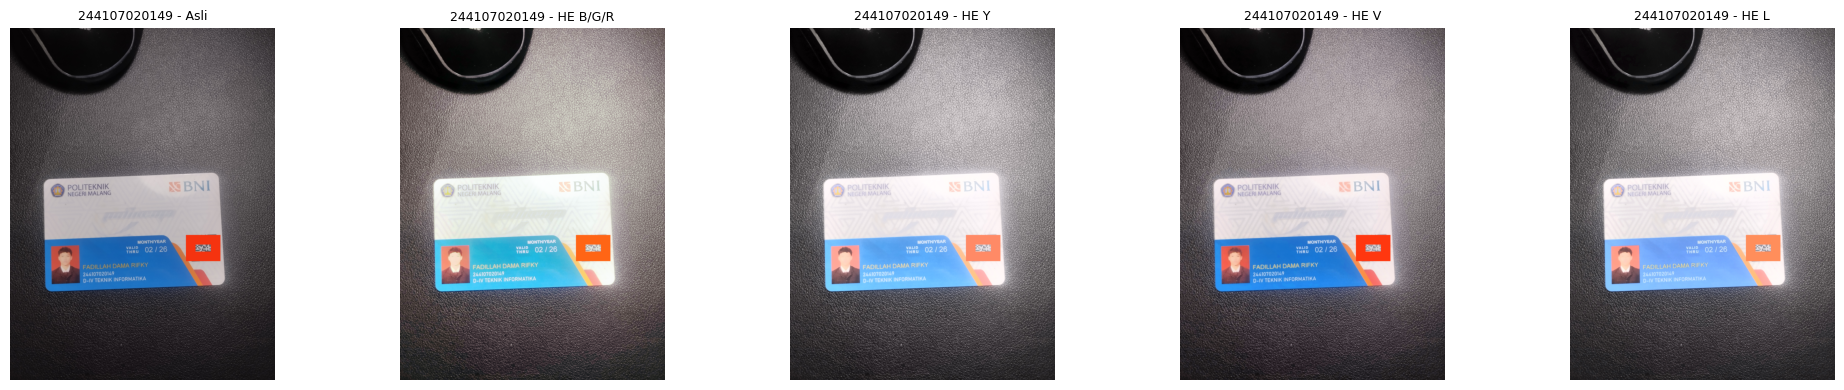

Cara | Pergeseran Hue (derajat) | Rerata kecerahan
Asli | 0.0 | 79.29
HE B/G/R | 51.9286 | 128.35
HE Y | 0.3417 | 128.01
HE V | 2.7305 | 114.33
HE L | 9.4181 | 123.39
Pergeseran terbesar: HE B/G/R = 51.9286 derajat


In [30]:
# Perulangan dipakai karena cara menampilkan kelima citra sama.
citra = [bgr, he_rgb, he_y, he_v, he_l]
judul = ['Asli', 'HE B/G/R', 'HE Y', 'HE V', 'HE L']
plt.figure(figsize=(20, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(cv.cvtColor(citra[i], cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + judul[i], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

# Cetak tabel angka untuk menjawab pertanyaan modul.
print('Cara | Pergeseran Hue (derajat) | Rerata kecerahan')
nilai_hue = []
for i in range(5):
    hue = geser_hue(bgr, citra[i]) * 2
    terang = cv.cvtColor(citra[i], cv.COLOR_BGR2GRAY).mean()
    nilai_hue.append(hue)
    print(judul[i], '|', round(hue, 4), '|', round(terang, 2))

# Cari nilai terbesar di antara empat metode ekualisasi, bukan citra asli.
hue_terbesar = max(nilai_hue[1:])
for i in range(1, 5):
    if nilai_hue[i] == hue_terbesar:
        print('Pergeseran terbesar:', judul[i], '=', round(hue_terbesar, 4), 'derajat')


### E2 PERCOBAAN 4 — Pembesaran teks KTM1d

Memperbesar area yang sama pada lima hasil untuk menilai keterbacaan dan membantu memilih kanal Y, V, atau L.

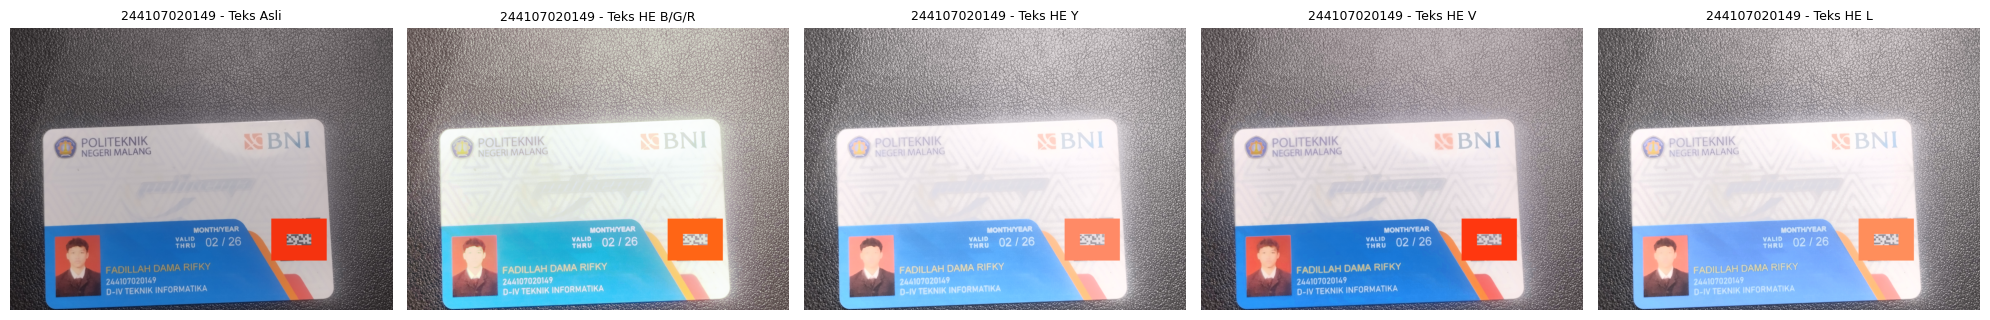

In [31]:
# Tentukan batas potongan dalam piksel berdasarkan ukuran gambar.
tinggi, lebar = bgr.shape[:2]
x1 = int(0.05 * lebar)
x2 = int(0.95 * lebar)
y1 = int(0.25 * tinggi)
y2 = int(0.75 * tinggi)

plt.figure(figsize=(20, 4))
for i in range(5):
    potongan = citra[i][y1:y2, x1:x2]
    plt.subplot(1, 5, i + 1)
    plt.imshow(cv.cvtColor(potongan, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - Teks ' + judul[i], fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()


### Jawaban pengamatan E2 Percobaan 4 — Nomor 1–3

| Cara | Pergeseran Hue (derajat) | Rerata kecerahan | Pengamatan visual KTM1d |
|---|---:|---:|---|
| Asli | 0,0000 | 79,29 | Kartu lebih gelap, tetapi warna biru dan oranye masih terlihat. |
| HE B/G/R | 51,9286 | 128,35 | Warna biru bergeser ke arah cyan dan warna kartu berubah cukup jelas. |
| HE Y | 0,3417 | 128,01 | Kartu lebih terang, tetapi bagian putih dan foto terlihat lebih pucat. |
| HE V | 2,7305 | 114,33 | Bagian biru dan tulisan terlihat lebih seimbang, tanpa seterang HE Y. |
| HE L | 9,4181 | 123,39 | Kartu lebih terang, tetapi bagian putih dan foto juga terlihat pucat. |

**1. Metode dengan pergeseran Hue terbesar**

Pergeseran Hue terbesar pada KTM1d dihasilkan oleh **HE B/G/R, yaitu 51,9286°**. Hal ini terjadi karena setiap kanal diekualisasi sendiri, sehingga perbandingan nilai B, G, dan R berubah. Akibatnya, warna hasil tidak lagi sama dengan warna awal.

**2. Penyebab pergeseran Hue tidak selalu nol**

Walaupun yang diubah hanya kanal terang, proses konversi kembali ke BGR melibatkan pembulatan nilai piksel. Nilai yang melewati batas juga dipotong ke rentang 0–255. Hal tersebut dapat mengubah perbandingan kanal warna, sehingga Hue hasilnya tidak selalu persis sama dengan citra asli.

**3. Kanal yang saya pilih**

Untuk tampilan foto KTM ini, saya memilih **kanal V**. Pada bagian biru yang memuat nama dan NIM, kontras tulisan masih terlihat dan warna kartu tidak sepucat hasil Y atau L. Pergeseran Hue-nya **2,7305°** dengan rerata kecerahan **114,33**.

Kanal Y memang memiliki pergeseran Hue lebih kecil, yaitu **0,3417°**, sehingga paling dekat dengan Hue asli berdasarkan angka. Namun, untuk pilihan tampilan, saya juga mempertimbangkan bagian putih dan foto yang terlihat lebih pucat pada HE Y. Jadi, pilihan V ini berdasarkan keseimbangan tampilan pada foto saya, bukan karena nilai Hue-nya paling kecil.

### E2 PERCOBAAN 4 — Analisis nomor 4: Proses CLAHE kanal Y

Menggunakan KTM1d dan parameter NIM untuk membandingkan CLAHE kanal Y dengan HE global kanal Y.

In [32]:
# PERTANYAAN LANJUTAN 4
bgr = cv.imread(file_d)
ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)

# HE global pada kanal Y.
he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

# CLAHE pada kanal Y, dengan parameter NIM.
clahe = cv.createCLAHE(clipLimit=PARAM['clip'],
                       tileGridSize=(PARAM['tile'], PARAM['tile']))
y_clahe = clahe.apply(y)
clahe_y = cv.cvtColor(cv.merge([y_clahe, cr, cb]), cv.COLOR_YCrCb2BGR)


### E2 PERCOBAAN 4 — Analisis nomor 4: Tampilan dan metrik

Menampilkan tiga citra, pergeseran Hue, rerata kecerahan, serta selisih metrik CLAHE terhadap HE.

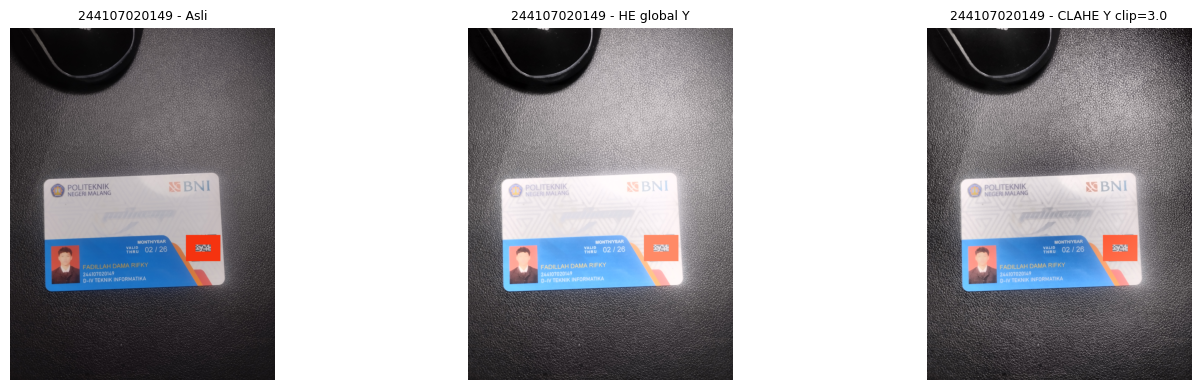

Cara | Geser Hue (derajat) | Rerata kecerahan
Asli | 0.0 | 79.29
HE global Y | 0.3417 | 128.01
CLAHE Y | 0.0602 | 111.13
Perubahan Hue (CLAHE - HE): -0.2815 derajat
Perubahan rerata terang (CLAHE - HE): -16.88


In [33]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - ' + 'Asli', fontsize=9)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cv.cvtColor(he_y, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - ' + 'HE global Y', fontsize=9)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv.cvtColor(clahe_y, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - ' + 'CLAHE Y clip=' + str(PARAM['clip']), fontsize=9)
plt.axis('off')

plt.tight_layout()
plt.show()

print('Cara | Geser Hue (derajat) | Rerata kecerahan')
citra = [bgr, he_y, clahe_y]
judul = ['Asli', 'HE global Y', 'CLAHE Y']
for i in range(3):
    hue = geser_hue(bgr, citra[i]) * 2
    terang = cv.cvtColor(citra[i], cv.COLOR_BGR2GRAY).mean()
    print(judul[i], '|', round(hue, 4), '|', round(terang, 2))

beda_hue = (geser_hue(bgr, clahe_y) - geser_hue(bgr, he_y)) * 2
beda_terang = cv.cvtColor(clahe_y, cv.COLOR_BGR2GRAY).mean() - cv.cvtColor(he_y, cv.COLOR_BGR2GRAY).mean()
print('Perubahan Hue (CLAHE - HE):', round(beda_hue, 4), 'derajat')
print('Perubahan rerata terang (CLAHE - HE):', round(beda_terang, 2))


### Jawaban pengamatan E2 Percobaan 4 — Nomor 4

CLAHE diterapkan pada kanal Y menggunakan **clipLimit = 3,0** dan **tileGridSize = (3, 3)** sesuai NIM saya.

| Metode | Pergeseran Hue (derajat) | Rerata kecerahan |
|---|---:|---:|
| HE global Y | 0,3417 | 128,01 |
| CLAHE Y | 0,0602 | 111,13 |

Dibandingkan HE global Y, CLAHE menurunkan pergeseran Hue sebesar **0,2815°** dan rerata kecerahan sebesar **16,88**. Jadi, pada gambar ini CLAHE lebih dekat dengan Hue asli dan tidak meningkatkan kecerahan sebanyak HE global. Nilai kecerahan yang lebih rendah tidak langsung berarti hasilnya lebih buruk, karena keterbacaan dan detail gambar juga perlu diperhatikan.

## E2 — PERTANYAAN PRAKTIKUM

Bagian ini khusus untuk **Pertanyaan 1 (ekualisasi global)** dan **Pertanyaan 2 (CLAHE)** pada citra KTM1a.


### E2 PERTANYAAN 1a — HE manual dan OpenCV pada KTM1a

Membaca ulang KTM1a, menjalankan kedua cara ekualisasi, dan menghitung selisih maksimum. Hasil ini juga menjadi tahap 2 E2 Percobaan 1–2.

In [23]:
# TAHAP 2
bgr = cv.imread(file_a)
gray = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)

# HE manual: frekuensi -> probabilitas -> CDF -> intensitas baru.
h = histogram_manual(gray)
p = h / gray.size
cdf = np.cumsum(p)
pemetaan = np.round(255 * cdf).astype(np.uint8)
manual = pemetaan[gray]

# HE menggunakan OpenCV.
opencv = cv.equalizeHist(gray)

# Konversi ke int16 agar pengurangan tidak berputar seperti pada uint8.
selisih = np.abs(manual.astype(np.int16) - opencv.astype(np.int16))
print('Selisih maksimum manual - OpenCV:', selisih.max())


Selisih maksimum manual - OpenCV: 0


### E2 PERTANYAAN 1b — Layout citra dan histogram KTM1a

Menampilkan citra asli, hasil HE manual, hasil HE OpenCV, dan ketiga histogram.

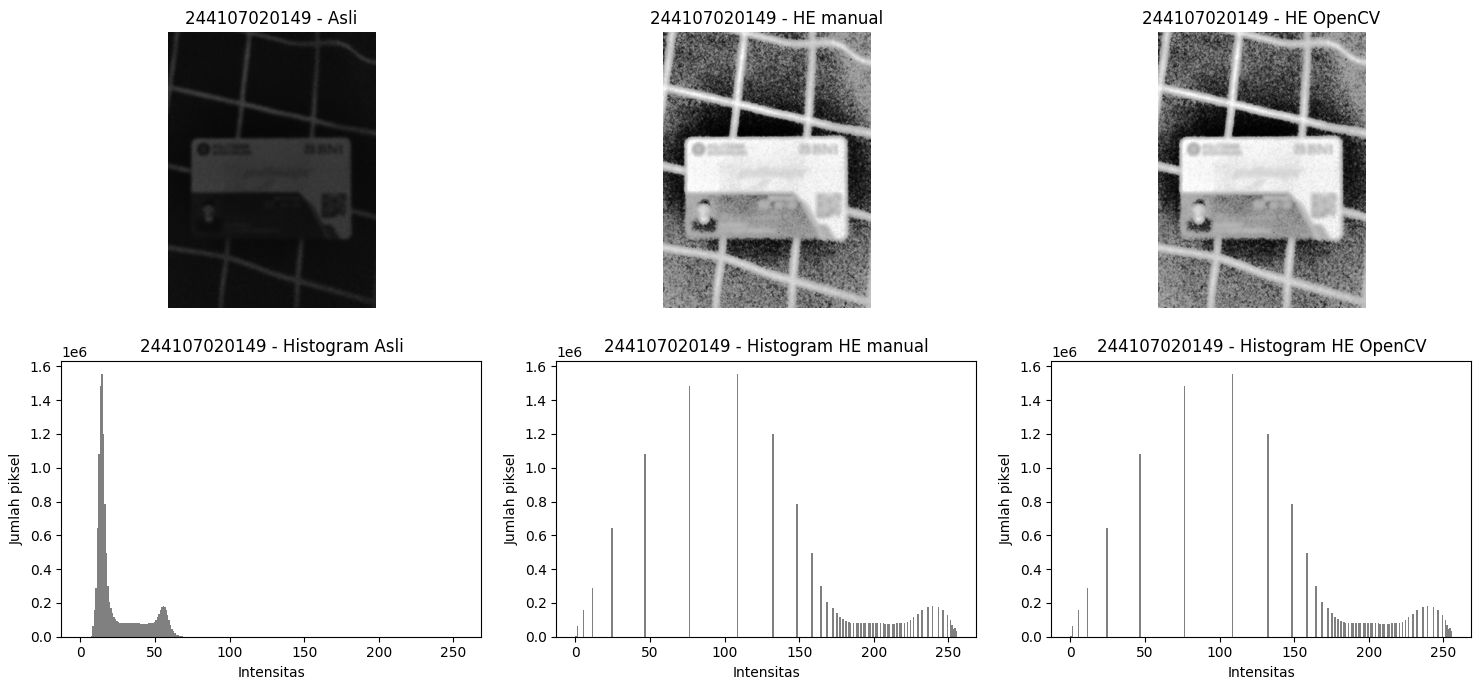

In [24]:
plt.figure(figsize=(15, 7))

plt.subplot(2, 3, 1)
plt.imshow(gray, cmap='gray', vmin=0, vmax=255)
plt.title(NIM + ' - Asli')
plt.axis('off')
plt.subplot(2, 3, 4)
plt.hist(gray.flatten(), bins=256, range=(0, 256), color='gray')
plt.title(NIM + ' - Histogram Asli')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah piksel')

plt.subplot(2, 3, 2)
plt.imshow(manual, cmap='gray', vmin=0, vmax=255)
plt.title(NIM + ' - HE manual')
plt.axis('off')
plt.subplot(2, 3, 5)
plt.hist(manual.flatten(), bins=256, range=(0, 256), color='gray')
plt.title(NIM + ' - Histogram HE manual')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah piksel')

plt.subplot(2, 3, 3)
plt.imshow(opencv, cmap='gray', vmin=0, vmax=255)
plt.title(NIM + ' - HE OpenCV')
plt.axis('off')
plt.subplot(2, 3, 6)
plt.hist(opencv.flatten(), bins=256, range=(0, 256), color='gray')
plt.title(NIM + ' - Histogram HE OpenCV')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah piksel')

plt.tight_layout()
plt.show()


### E2 PERTANYAAN 1c — PSNR KTM1a

Menghitung PSNR terhadap citra asli untuk HE manual dan OpenCV. Hasilnya menjadi dasar penjelasan hubungan PSNR dengan perubahan intensitas dan keterbacaan.

In [25]:
# PSNR manual: ubah ke float sebelum menghitung selisih dan kuadrat.
mse_manual = np.mean((gray.astype(np.float64) - manual.astype(np.float64)) ** 2)
if mse_manual == 0:
    psnr_manual = float('inf')
else:
    psnr_manual = 10 * np.log10(255 ** 2 / mse_manual)

mse_opencv = np.mean((gray.astype(np.float64) - opencv.astype(np.float64)) ** 2)
if mse_opencv == 0:
    psnr_opencv = float('inf')
else:
    psnr_opencv = 10 * np.log10(255 ** 2 / mse_opencv)

print('PSNR asli - manual:', psnr_manual, 'dB')
print('PSNR asli - OpenCV:', psnr_opencv, 'dB')


PSNR asli - manual: 6.165983027039278 dB
PSNR asli - OpenCV: 6.165983027039278 dB


### Jawaban E2 Pertanyaan 1 — Ekualisasi global

**a. Perbandingan manual dan OpenCV**

Pada KTM1a, selisih maksimum hasil manual dan OpenCV adalah **0**. Artinya, kedua cara menghasilkan citra yang sama pada percobaan ini. Rumus manual menggunakan pembulatan `255 × CDF`, sedangkan OpenCV umumnya mengurangi CDF pertama yang tidak nol sebelum melakukan normalisasi. Pada gambar ini, perbedaan cara tersebut tidak menghasilkan perbedaan nilai piksel setelah pembulatan. Jadi, hasil nol ini tidak berarti keduanya pasti selalu sama untuk semua gambar.

**b. Perubahan citra dan histogram**

Citra asli KTM1a sangat gelap. Setelah ekualisasi, bagian kartu menjadi jauh lebih terang dan intensitasnya tersebar lebih luas. Namun, noise juga terlihat lebih kuat dan beberapa bagian terang tampak berlebihan. Bentuk kartu lebih terlihat, tetapi nama dan NIM masih buram. Jadi, perbaikan kecerahan belum tentu membuat semua tulisan langsung terbaca.

**c. Penjelasan PSNR**

PSNR hasil manual dan OpenCV terhadap citra asli sama, yaitu sekitar **6,17 dB**. Nilai ini menunjukkan bahwa intensitas hasil ekualisasi cukup jauh berbeda dari gambar awal yang gelap.

PSNR mengukur kemiripan nilai piksel dengan citra acuan. Ketika ekualisasi mengubah intensitas untuk meningkatkan kontras, selisih terhadap citra asli membesar sehingga PSNR bisa rendah, walaupun bagian gambar menjadi lebih terlihat. Jika citra dibandingkan dengan dirinya sendiri, PSNR bernilai tak hingga karena tidak ada selisih.

Jadi, menurut saya **PSNR tidak cukup jika digunakan sendiri untuk menilai keterbacaan**. Keterbacaan tetap perlu dilihat dari bentuk huruf dan kejelasan nama/NIM, bukan hanya dari nilai PSNR.

### E2 PERTANYAAN 2a — CLAHE dibandingkan HE global

Menerapkan CLAHE dengan parameter NIM pada KTM1a dan menampilkan perbandingannya dengan HE global.

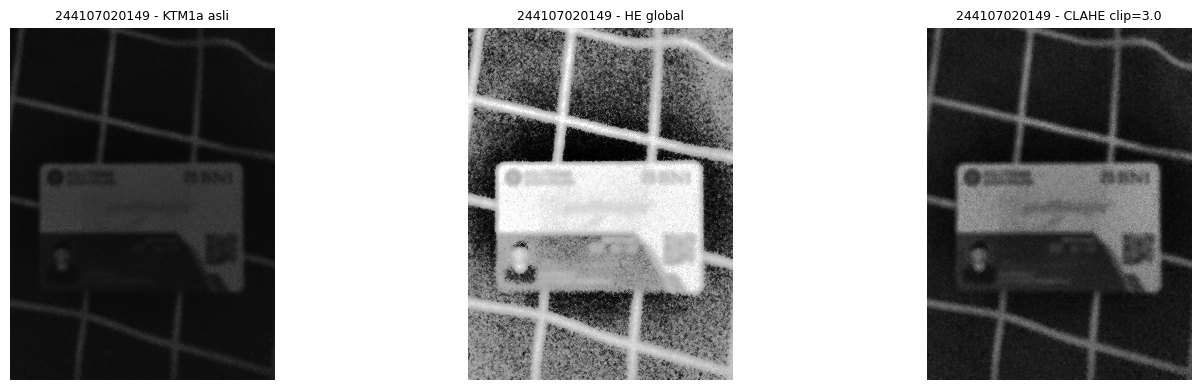

In [34]:
# E2 PERTANYAAN 2a

bgr = cv.imread(file_a)
gray = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)
global_a = cv.equalizeHist(gray)

clahe = cv.createCLAHE(clipLimit=PARAM['clip'],
                       tileGridSize=(PARAM['tile'], PARAM['tile']))
clahe_a = clahe.apply(gray)
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
plt.title(NIM + ' - ' + 'KTM1a asli', fontsize=9)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(global_a, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
plt.title(NIM + ' - ' + 'HE global', fontsize=9)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(clahe_a, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
plt.title(NIM + ' - ' + 'CLAHE clip=' + str(PARAM['clip']), fontsize=9)
plt.axis('off')

plt.tight_layout()
plt.show()


### E2 PERTANYAAN 2a — Pembesaran nama dan NIM

Memotong area teks yang sama pada citra asli, HE global, dan CLAHE untuk membandingkan keterbacaan.

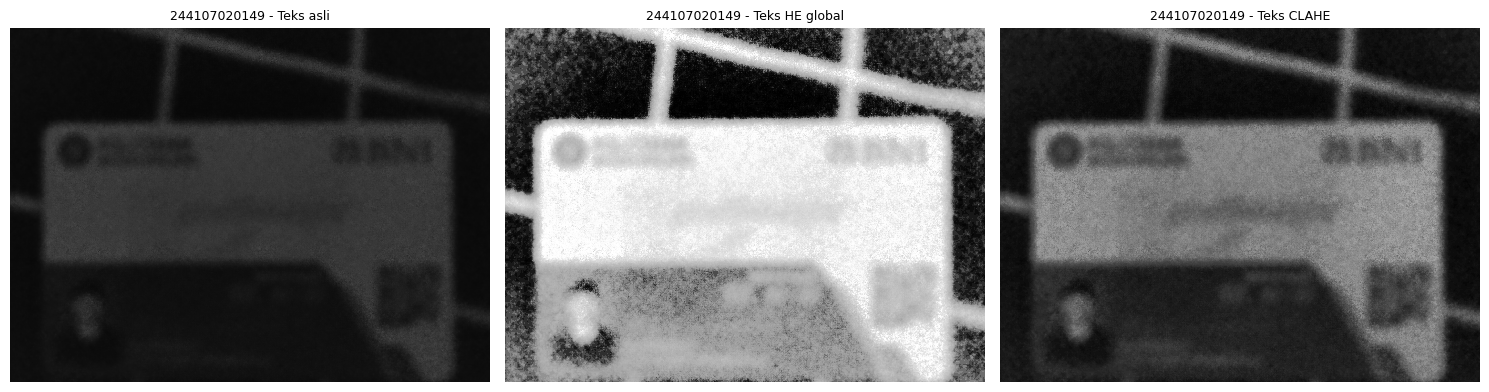

In [35]:
# Atur potongan agar mencakup nama dan NIM pada KTM1a.
tinggi, lebar = gray.shape
x1 = int(0.05 * lebar)
x2 = int(0.95 * lebar)
y1 = int(0.25 * tinggi)
y2 = int(0.75 * tinggi)

teks_asli = gray[y1:y2, x1:x2]
teks_global = global_a[y1:y2, x1:x2]
teks_clahe = clahe_a[y1:y2, x1:x2]
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(teks_asli, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
plt.title(NIM + ' - ' + 'Teks asli', fontsize=9)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(teks_global, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
plt.title(NIM + ' - ' + 'Teks HE global', fontsize=9)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(teks_clahe, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
plt.title(NIM + ' - ' + 'Teks CLAHE', fontsize=9)
plt.axis('off')

plt.tight_layout()
plt.show()


### Jawaban E2 Pertanyaan 2a

Pada KTM1a, saya lebih memilih hasil **CLAHE** karena tampilannya lebih seimbang daripada HE global. HE global memang membuat kartu lebih terang, tetapi noise menjadi sangat terlihat dan bagian putih kartu tampak terlalu terang. Pada CLAHE, bentuk kartu dan beberapa tulisan di bagian atas masih terlihat dengan peningkatan terang yang lebih terkendali.

Namun, pada hasil pembesaran, **nama dan NIM masih belum terbaca dengan jelas pada kedua metode**. Jadi, saya tidak bisa menyimpulkan bahwa CLAHE sudah berhasil memperjelas semua tulisan. Citra awal yang sangat gelap dan buram membatasi detail yang bisa diperbaiki dengan ekualisasi.

### E2 PERTANYAAN 2b — Percobaan tiga clipLimit tambahan

Membandingkan nilai clipLimit pribadi dan tiga nilai lain dengan tileGridSize yang tetap.

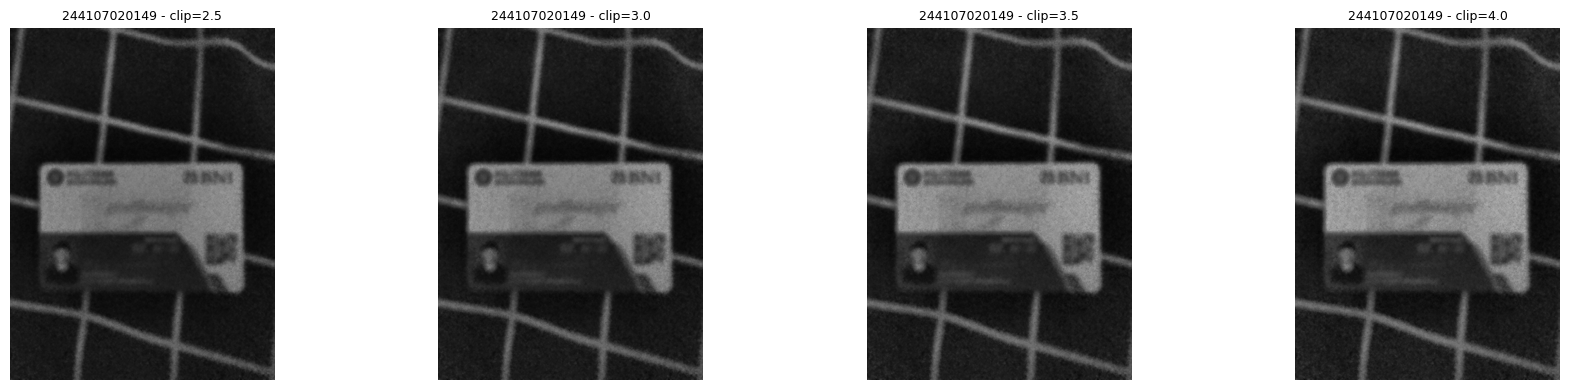

Clip dari NIM: 3.0
Nilai yang dibandingkan: [2.5, 3.0, 3.5, 4.0]
Tile tetap: 3


In [36]:
# PERTANYAAN 2b
# Nilai utama dan tiga nilai lain. Tile tetap sama.
clip = PARAM['clip']
daftar_clip = [clip - 0.5, clip, clip + 0.5, clip + 1.0]
hasil_clip = []

bgr = cv.imread(file_a)
gray = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)
plt.figure(figsize=(18, 4))
for i in range(4):
    clahe = cv.createCLAHE(clipLimit=daftar_clip[i],
                           tileGridSize=(PARAM['tile'], PARAM['tile']))
    hasil = clahe.apply(gray)
    hasil_clip.append(hasil)

    plt.subplot(1, 4, i + 1)
    plt.imshow(hasil, cmap='gray', vmin=0, vmax=255)
    plt.title(NIM + ' - clip=' + str(daftar_clip[i]), fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()
print('Clip dari NIM:', clip)
print('Nilai yang dibandingkan:', daftar_clip)
print('Tile tetap:', PARAM['tile'])


### E2 PERTANYAAN 2b — Pengamatan teks dan noise

Memperbesar teks serta latar polos pada keempat hasil CLAHE untuk memilih clipLimit terbaik dan mengamati noise.

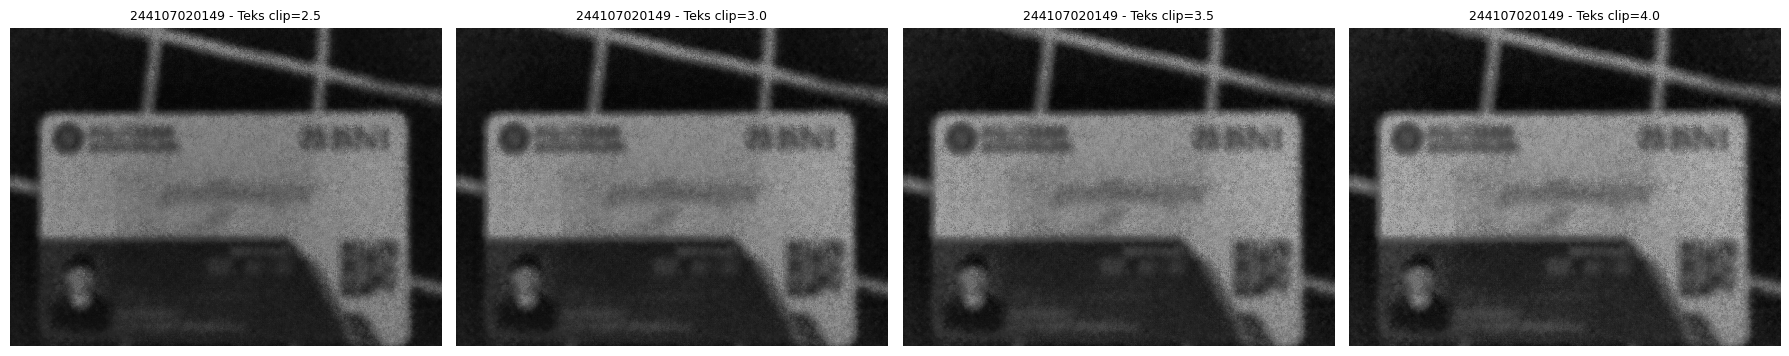

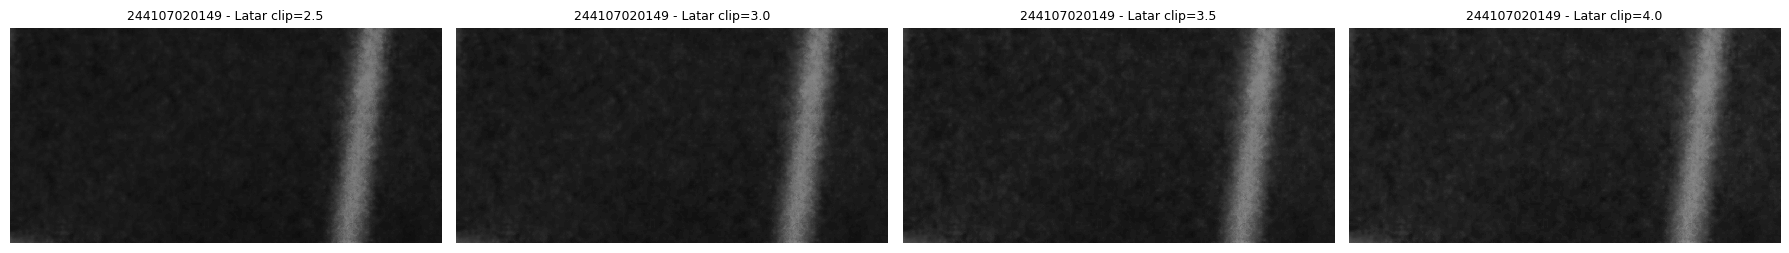

In [37]:
# Perbesar teks yang sama pada keempat hasil.
plt.figure(figsize=(18, 4))
for i in range(4):
    potongan = hasil_clip[i][y1:y2, x1:x2]
    plt.subplot(1, 4, i + 1)
    plt.imshow(potongan, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
    plt.title(NIM + ' - Teks clip=' + str(daftar_clip[i]), fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

# Pilih daerah latar yang polos untuk mengamati noise.
# Ganti persentase ini jika area tersebut berisi teks atau pola cetak.
tinggi, lebar = gray.shape
nx1 = int(0.05 * lebar)
nx2 = int(0.45 * lebar)
ny1 = int(0.05 * tinggi)
ny2 = int(0.20 * tinggi)

plt.figure(figsize=(18, 4))
for i in range(4):
    potongan = hasil_clip[i][ny1:ny2, nx1:nx2]
    plt.subplot(1, 4, i + 1)
    plt.imshow(potongan, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
    plt.title(NIM + ' - Latar clip=' + str(daftar_clip[i]), fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()


### Jawaban E2 Pertanyaan 2b

Nilai clipLimit yang saya bandingkan adalah **2,5; 3,0; 3,5; dan 4,0**, dengan tileGridSize tetap **(3, 3)**. Dari hasil pembesaran, saya memilih **clipLimit 3,0** sebagai kompromi. Bagian kartu sudah lebih terlihat dibandingkan citra awal, tetapi penguatan bintiknya belum sebesar pada nilai yang lebih tinggi.

Perbedaan keempat hasil tidak terlalu besar, dan nama/NIM tetap buram. Saat clipLimit dinaikkan ke **3,5 dan 4,0**, bintik lebih menonjol pada area gelap di sekitar kartu dan permukaan kartu yang relatif rata. Bintik sebenarnya sudah ada pada clipLimit 2,5, jadi bukan baru muncul setelah nilainya dinaikkan.

Pada potongan berjudul “Latar”, area yang terlihat masih berupa latar di luar kartu dengan garis terang. Karena itu, potongan tersebut saya gunakan untuk melihat penguatan bintik di latar, bukan sebagai bukti khusus noise pada bagian polos kartu. Pilihan clipLimit 3,0 ini merupakan penilaian visual; hasilnya belum menunjukkan peningkatan keterbacaan yang besar.

# E3 — TUGAS PRAKTIKUM DITHERING

Modul memberi nama bagian ini **Tugas Praktikum**, dengan nomor 1 dan 2; tidak ada kelompok terpisah “Percobaan E3” dan “Pertanyaan E3”.


### E3 TUGAS 1 — Definisi fungsi Floyd–Steinberg

Fungsi menguantisasi intensitas dan menyebarkan error ke empat tetangga.

In [49]:
# TUGAS 1
def floyd_steinberg(gray, L=2):
    img = gray.astype(np.float32).copy()
    step = 255.0 / (L - 1)
    H, W = img.shape
    for y in range(H):
        for x in range(W):
            lama = img[y, x]
            baru = np.round(lama / step) * step
            img[y, x] = baru
            error = lama - baru
            if x + 1 < W:
                img[y, x + 1] += error * 7 / 16
            if x > 0 and y + 1 < H:
                img[y + 1, x - 1] += error * 3 / 16
            if y + 1 < H:
                img[y + 1, x] += error * 5 / 16
            if x + 1 < W and y + 1 < H:
                img[y + 1, x + 1] += error * 1 / 16
    return np.clip(img, 0, 255).astype(np.uint8)


### E3 TUGAS 1 — Tahap 1: Lena

Menampilkan hasil dithering dengan dua tingkat intensitas.

Level yang digunakan: 2
Intensitas yang muncul: [  0 255]


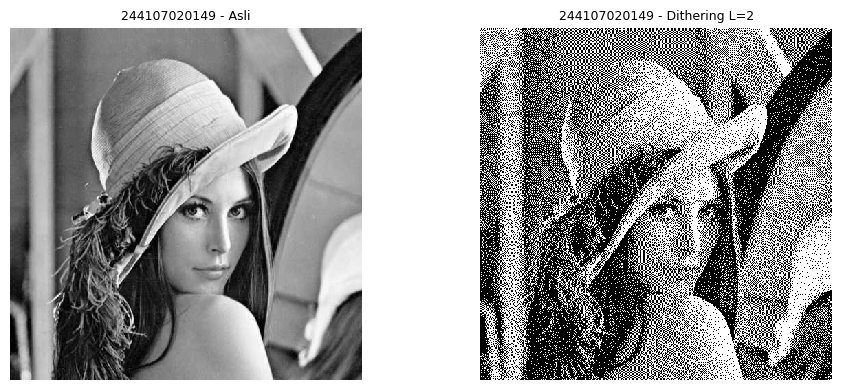

In [50]:
# TAHAP 1

bgr = cv.imread(file_lena)
gray = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)
L = 2
dither = floyd_steinberg(gray, L=L)
print('Level yang digunakan:', L)
print('Intensitas yang muncul:', np.unique(dither))
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
plt.title(NIM + ' - ' + 'Asli', fontsize=9)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(dither, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
plt.title(NIM + ' - ' + 'Dithering L=' + str(L), fontsize=9)
plt.axis('off')

plt.tight_layout()
plt.show()


### E3 TUGAS 1 — Tahap 2: KTM1b

Menampilkan hasil dithering dengan delapan tingkat intensitas sesuai NIM.

Level yang digunakan: 8
Intensitas yang muncul: [  0  36  72 109 145 182 218 254]


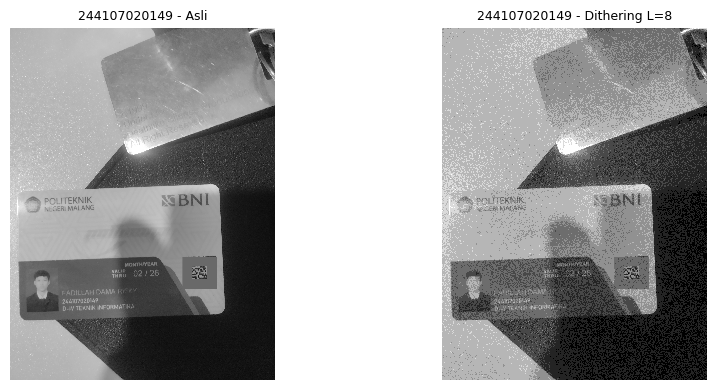

In [51]:
# TAHAP 2

bgr = cv.imread(file_b)
gray = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)
L = PARAM['L']
dither = floyd_steinberg(gray, L=L)
print('Level yang digunakan:', L)
print('Intensitas yang muncul:', np.unique(dither))
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
plt.title(NIM + ' - ' + 'Asli', fontsize=9)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(dither, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
plt.title(NIM + ' - ' + 'Dithering L=' + str(L), fontsize=9)
plt.axis('off')

plt.tight_layout()
plt.show()


### Hasil E3 Tugas 1

Pada Lena digunakan **L = 2**, sehingga intensitas hasil hanya **0 dan 255**. Pada KTM1b digunakan **L = 8** sesuai parameter NIM. Intensitas yang tercetak pada output adalah **0, 36, 72, 109, 145, 182, 218, dan 254**.

Dithering mengurangi jumlah tingkat keabuan, tetapi menyebarkan error ke piksel di sekitarnya agar kesan gradasi tetap terlihat. Karena itu, hasilnya membentuk pola titik. Pada KTM1b tersedia lebih banyak tingkat abu-abu daripada contoh Lena, sehingga gradasinya tidak hanya berupa hitam dan putih.

Nilai paling tinggi pada output saya tercetak 254. Nilai ini saya tulis sesuai hasil program. Perhitungan menggunakan bilangan pecahan dengan `float32`, kemudian dikonversi ke `uint8`, sehingga nilai yang sangat dekat dengan 255 dapat terpotong menjadi 254.

### E3 TUGAS 2 — Tahap 1: Lena LC

Membandingkan dithering langsung dengan ekualisasi sebelum dithering pada citra contoh.

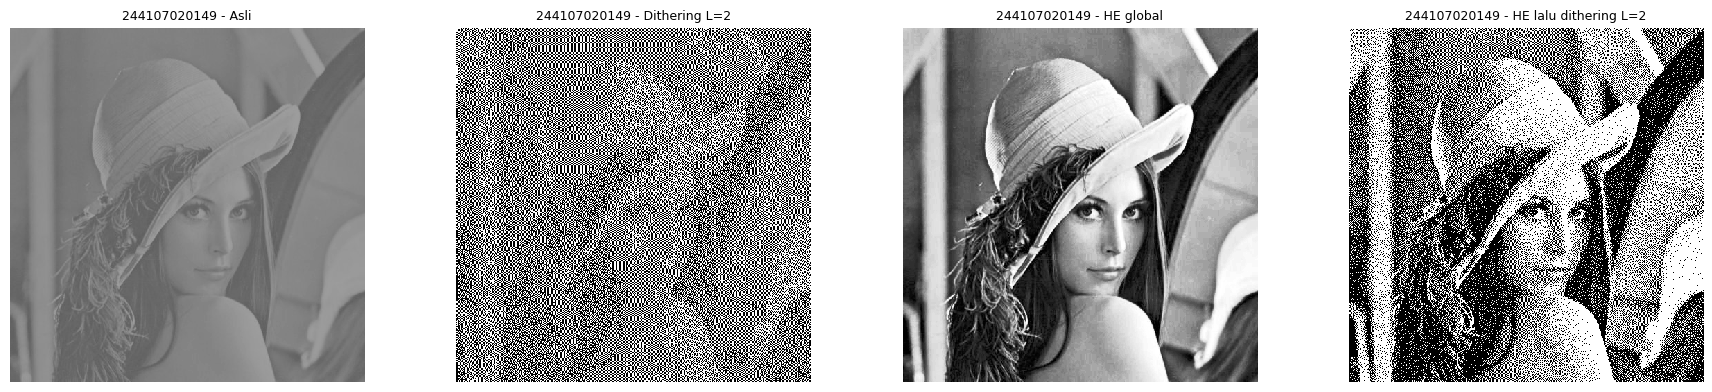

In [52]:
# TUGAS 2

# TAHAP 1

bgr = cv.imread(file_lena_lc)
gray = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)
L = 2

# Jalur pertama: dithering langsung dari grayscale.
langsung = floyd_steinberg(gray, L=L)

# Jalur kedua: ekualisasi dahulu, kemudian dithering.
he = cv.equalizeHist(gray)
he_dither = floyd_steinberg(he, L=L)
plt.figure(figsize=(18, 4))

plt.subplot(1, 4, 1)
plt.imshow(gray, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
plt.title(NIM + ' - ' + 'Asli', fontsize=9)
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(langsung, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
plt.title(NIM + ' - ' + 'Dithering L=' + str(L), fontsize=9)
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(he, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
plt.title(NIM + ' - ' + 'HE global', fontsize=9)
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(he_dither, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
plt.title(NIM + ' - ' + 'HE lalu dithering L=' + str(L), fontsize=9)
plt.axis('off')

plt.tight_layout()
plt.show()


### E3 TUGAS 2 — Tahap 2: KTM1a

Membandingkan kedua urutan proses pada citra pribadi.

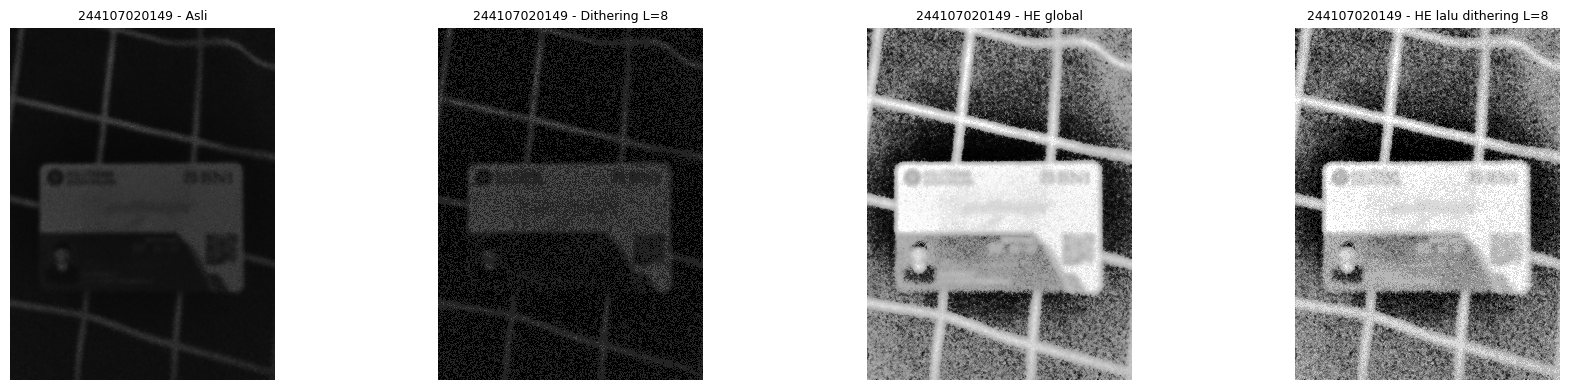

In [53]:
# TAHAP 2

bgr = cv.imread(file_a)
gray = cv.cvtColor(bgr, cv.COLOR_BGR2GRAY)
L = PARAM['L']

# Jalur pertama: dithering langsung dari grayscale.
langsung = floyd_steinberg(gray, L=L)

# Jalur kedua: ekualisasi dahulu, kemudian dithering.
he = cv.equalizeHist(gray)
he_dither = floyd_steinberg(he, L=L)
plt.figure(figsize=(18, 4))

plt.subplot(1, 4, 1)
plt.imshow(gray, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
plt.title(NIM + ' - ' + 'Asli', fontsize=9)
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(langsung, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
plt.title(NIM + ' - ' + 'Dithering L=' + str(L), fontsize=9)
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(he, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
plt.title(NIM + ' - ' + 'HE global', fontsize=9)
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(he_dither, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
plt.title(NIM + ' - ' + 'HE lalu dithering L=' + str(L), fontsize=9)
plt.axis('off')

plt.tight_layout()
plt.show()


### E3 TUGAS 2 — Pembesaran teks KTM1a

Menilai kejelasan tulisan pada potongan yang sama dari kedua hasil.

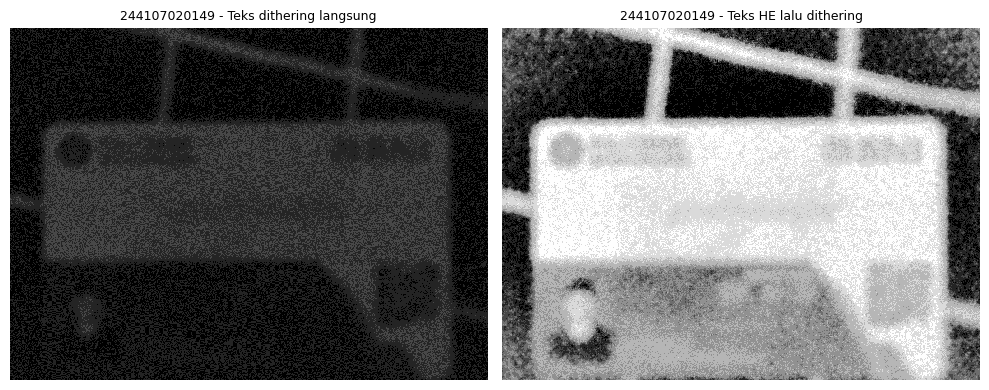

In [54]:
# KTM1a: perbesar area teks yang sama pada kedua jalur.
teks_langsung = langsung[y1:y2, x1:x2]
teks_he_dither = he_dither[y1:y2, x1:x2]
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(teks_langsung, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
plt.title(NIM + ' - ' + 'Teks dithering langsung', fontsize=9)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(teks_he_dither, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
plt.title(NIM + ' - ' + 'Teks HE lalu dithering', fontsize=9)
plt.axis('off')

plt.tight_layout()
plt.show()


### Jawaban E3 Tugas 2

Pada KTM1a, dithering langsung menghasilkan gambar yang masih gelap sehingga tulisan sulit dibedakan dari latarnya. Setelah dilakukan HE terlebih dahulu, bentuk kartu dan beberapa bagian tulisan lebih terlihat karena perbedaan intensitas menjadi lebih besar.

Jika dibandingkan, saya memilih urutan **grayscale → histogram equalization → Floyd–Steinberg** untuk memperlihatkan bagian kartu pada gambar ini. Namun, hasilnya juga lebih berbintik dan ada bagian yang terlalu terang. Nama dan NIM pada pembesaran masih belum terbaca jelas.

Jadi, HE sebelum dithering membantu meningkatkan tampilan detail dibandingkan dithering langsung, tetapi belum cukup untuk membuat teks pada foto KTM1a benar-benar terbaca. Kedua jalur memakai **L = 8**, sehingga perbandingannya menggunakan jumlah level yang sama.

## Kesimpulan

Dari praktikum ini, saya memahami bahwa histogram bisa digunakan untuk melihat sebaran intensitas dan kondisi terang-gelap citra. Histogram manual, NumPy, dan OpenCV menghasilkan nilai yang sama pada gambar yang saya gunakan.

HE dan CLAHE dapat membantu memperjelas tampilan gambar, tetapi peningkatan terang juga bisa memperkuat noise. Pada foto KTM1a yang sangat gelap dan buram, perbaikan kontras belum membuat nama dan NIM terbaca jelas. Dithering mengurangi tingkat keabuan sambil mempertahankan kesan gradasi melalui penyebaran error. Jadi, penilaian hasil perlu melihat perubahan gambar secara langsung dan tidak hanya mengandalkan satu angka.

## Catatan kesesuaian data dengan modul

Modul meminta citra kartu di-crop agar tidak ada background. Pada output notebook ini, beberapa gambar masih memuat latar di luar kartu. Jadi, histogram, CDF, rerata intensitas, serta metrik seluruh gambar juga dipengaruhi latar tersebut. Jawaban di atas mengikuti output yang tersimpan sekarang. Jika gambar di-crop ulang, hasil angka dan pengamatannya perlu dihitung ulang. Kode dan output asli tetap dipertahankan pada perapian ini.
